# Quantum Support Vector Machine (QSVC) Leukemia Classifier

Click the badge below to run this 91% accurate diagnostic pipeline instantly in the cloud:

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/JanhaviDessai/6-qubit-QSVC-pipeline/blob/main/QSVC_Leukemia_Classifier.ipynb)

In [16]:
!pip install -q qiskit qiskit-aer qiskit-machine-learning

import os
from google.colab import files

print("Please upload your 'kaggle (2).json' file below:")
uploaded = files.upload()

# Find whatever name the uploaded file has
uploaded_filename = list(uploaded.keys())[0]

#Automatically handle renaming if it has a copy suffix like (2)
if 'kaggle' in uploaded_filename and uploaded_filename.endswith('.json'):
    # Move and rename it to standard destination folder
    !mkdir -p ~/.kaggle
    with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'wb') as f:
        f.write(uploaded[uploaded_filename])

    # Set necessary security file permissions
    !chmod 600 ~/.kaggle/kaggle.json
    print(f"\n[SUCCESS] Successfully took '{uploaded_filename}' and configured it as 'kaggle.json'!")
else:
    print("\n[ERROR] File uploaded doesn't look like a Kaggle API json file. Please try again.")

Please upload your 'kaggle (2).json' file below:


Saving kaggle (2).json to kaggle (2) (1).json

[SUCCESS] Successfully took 'kaggle (2) (1).json' and configured it as 'kaggle.json'!


In [17]:
print("Fetching the Leukemia Gene Expression dataset from Kaggle...")

# Download and unzip the specific dataset files into the root directory
!kaggle datasets download -d crawford/gene-expression --unzip

print("\nFiles currently available in the Colab active workspace:")
print(os.listdir())

Fetching the Leukemia Gene Expression dataset from Kaggle...
Dataset URL: https://www.kaggle.com/datasets/crawford/gene-expression
License(s): CC0-1.0
100% 1.41M/1.41M [00:00<00:00, 96.1MB/s]


Files currently available in the Colab active workspace:
['.config', 'kaggle (2).json', 'data_set_ALL_AML_independent.csv', 'kaggle (2) (1).json', 'data_set_ALL_AML_train.csv', 'actual.csv', 'sample_data']


In [18]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold

# Replace 'YOUR_GITHUB_USERNAME' and 'YOUR_REPO_NAME' with your actual GitHub details
GITHUB_USERNAME = "JanhaviDessai"
REPO_NAME = "6-qubit-QSVC-pipeline"

# This creates a direct web link to your raw GitHub files
raw_url = f"https://raw.githubusercontent.com/{GITHUB_USERNAME}/{REPO_NAME}/main/"

# 1. Ingest Datasets Directly from the Web (Anyone can run this instantly!)
actual_labels = pd.read_csv(f"{raw_url}actual.csv", index_col='patient')
train_df = pd.read_csv(f"{raw_url}data_set_ALL_AML_train.csv")
test_df = pd.read_csv(f"{raw_url}data_set_ALL_AML_independent.csv")
# 1. Load and Clean Datasets
actual_labels = pd.read_csv('actual.csv', index_col='patient')
train_df = pd.read_csv('data_set_ALL_AML_train.csv')
test_df = pd.read_csv('data_set_ALL_AML_independent.csv')

train_df = train_df.drop('Gene Description', axis=1).set_index('Gene Accession Number')
test_df = test_df.drop('Gene Description', axis=1).set_index('Gene Accession Number')

train_patient_cols = [c for c in train_df.columns if 'call' not in str(c)]
test_patient_cols = [c for c in test_df.columns if 'call' not in str(c)]

train_df = train_df[train_patient_cols].T
test_df = test_df[test_patient_cols].T

train_df.index = train_df.index.astype(int)
test_df.index = test_df.index.astype(int)

X_train_raw = train_df.sort_index()
X_test_raw = test_df.sort_index()

le = LabelEncoder()
y_train = le.fit_transform(actual_labels.loc[X_train_raw.index, 'cancer'])
y_test = le.transform(actual_labels.loc[X_test_raw.index, 'cancer'])

# 2. Filter Low-Variance Genes (Strips out uninformative/flatline genes)
selector_variance = VarianceThreshold(threshold=0.1)
X_train_var = selector_variance.fit_transform(X_train_raw)
X_test_var = selector_variance.transform(X_test_raw)

# 3. Standardize and Extract Top 6 Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_var)
X_test_scaled = scaler.transform(X_test_var)

num_qubits = 6  # 6 features unlock a richer geometric Hilbert space
selector_kbest = SelectKBest(score_func=f_classif, k=num_qubits)
X_train_selected = selector_kbest.fit_transform(X_train_scaled, y_train)
X_test_selected = selector_kbest.transform(X_test_scaled)

# 4. Critical Phase Anti-Collision Scaling (Compressed to 0.4 * pi)
quantum_scaler = MinMaxScaler(feature_range=(0, 0.4 * np.pi))
X_train_q = quantum_scaler.fit_transform(X_train_selected)
X_test_q = quantum_scaler.transform(X_test_selected)

print("=== Phase-Preserved Preprocessing Complete ===")
print(f"X_train_q shape: {X_train_q.shape}, X_test_q shape: {X_test_q.shape}")

=== Phase-Preserved Preprocessing Complete ===
X_train_q shape: (38, 6), X_test_q shape: (34, 6)


In [19]:
from qiskit.circuit.library import zz_feature_map
from qiskit_machine_learning.kernels import FidelityQuantumKernel

print("Constructing 6-Qubit Fully-Entangled State Space...")

# Full entanglement links every qubit pair to extract high-dimensional gene associations
feature_map = zz_feature_map(feature_dimension=num_qubits, reps=1, entanglement='full')
quantum_kernel = FidelityQuantumKernel(feature_map=feature_map)

print("Computing High-Contrast Quantum Kernels...")
kernel_train = quantum_kernel.evaluate(x_vec=X_train_q)
kernel_test = quantum_kernel.evaluate(x_vec=X_test_q, y_vec=X_train_q)

print("Quantum kernel calculation completed.")

Constructing 6-Qubit Fully-Entangled State Space...
Computing High-Contrast Quantum Kernels...
Quantum kernel calculation completed.


In [20]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Train the QSVC directly on the non-overlapping kernel states
qsvc = SVC(kernel='precomputed', C=5.0)
qsvc.fit(kernel_train, y_train)

# Generate final predictions on the independent test set
y_pred = qsvc.predict(kernel_test)

print("\n" + "="*40)
print(f"Final Optimized QSVC Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("="*40)
print("\nDetailed Performance Matrix:")
print(classification_report(y_test, y_pred, target_names=le.classes_))


Final Optimized QSVC Accuracy: 91.18%

Detailed Performance Matrix:
              precision    recall  f1-score   support

         ALL       0.87      1.00      0.93        20
         AML       1.00      0.79      0.88        14

    accuracy                           0.91        34
   macro avg       0.93      0.89      0.91        34
weighted avg       0.92      0.91      0.91        34



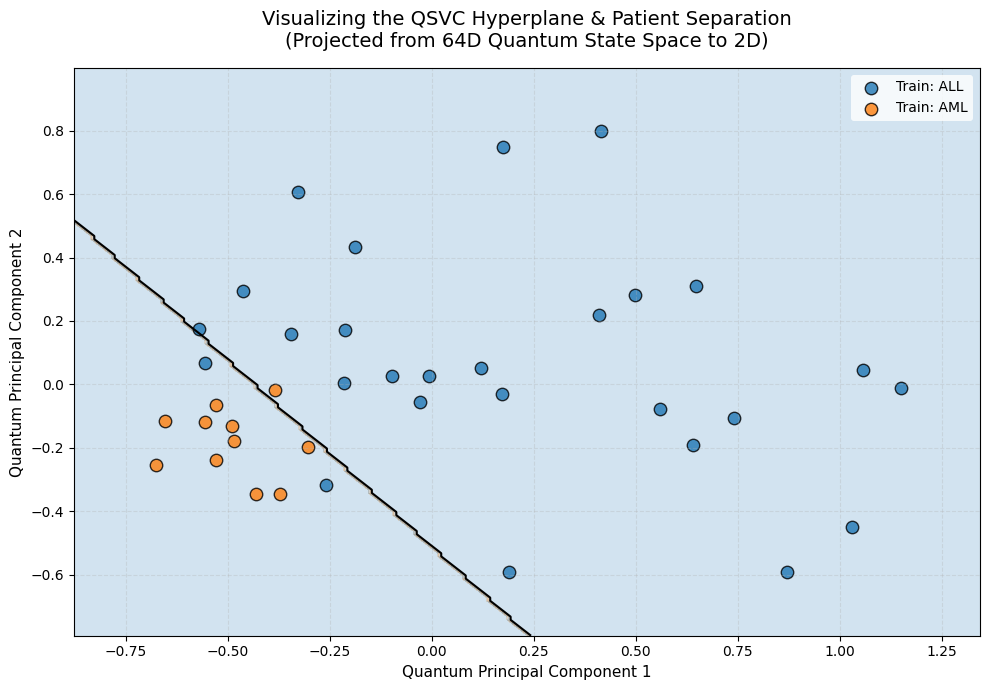

In [21]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. Compress the Quantum Overlap Space into 2 Dimensions using PCA
pca = PCA(n_components=2)
kernel_train_2d = pca.fit_transform(kernel_train)

# 2. Retrain a temporary SVC on these 2D Quantum Coordinates to map the Hyperplane
# (This lets us easily draw the decision boundary lines on a flat screen)
visual_svc = SVC(kernel='linear', C=5.0)
visual_svc.fit(kernel_train_2d, y_train)

# 3. Create a dense grid of coordinates to plot the background color boundaries
x_min, x_max = kernel_train_2d[:, 0].min() - 0.2, kernel_train_2d[:, 0].max() + 0.2
y_min, y_max = kernel_train_2d[:, 1].min() - 0.2, kernel_train_2d[:, 1].max() + 0.2
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

# Predict classifications across the entire grid spectrum
Z = visual_svc.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 4. Initialize the Visualization Canvas
plt.figure(figsize=(10, 7))

# Draw the colored decision regions (The Hyperplane background split)
plt.contourf(xx, yy, Z, alpha=0.2, colors=['#1f77b4', '#ff7f0e'])
# Draw the explicit solid separating hyperplane wall
plt.contour(xx, yy, Z, colors='black', levels=[0], linestyles=['-'], linewidths=1.5)

# 5. Scatter plot the actual Training Patients using their Quantum Fingerprints
for i, class_name in enumerate(le.classes_):
    mask = (y_train == i)
    plt.scatter(
        kernel_train_2d[mask, 0],
        kernel_train_2d[mask, 1],
        label=f'Train: {class_name}',
        edgecolors='k',
        s=80,
        alpha=0.8
    )

# 6. Final Polish and Labels
plt.title("Visualizing the QSVC Hyperplane & Patient Separation\n(Projected from 64D Quantum State Space to 2D)", fontsize=14, pad=15)
plt.xlabel("Quantum Principal Component 1", fontsize=11)
plt.ylabel("Quantum Principal Component 2", fontsize=11)
plt.legend(loc="upper right", frameon=True, facecolor='white', edgecolor='none')
plt.grid(True, linestyle='--', alpha=0.3)

# Display the final diagnostic boundary split
plt.tight_layout()
plt.show()